# Proyek Analisis Data: [bike Sharing Dataset]
- **Nama:** Anwar Ibrahim
- **Email:** cdcc229d6y1387@student.devacademy.id
- **ID Dicoding:** CDCC229D6Y1387

## Menentukan Pertanyaan Bisnis

- Bagaimana hubungan kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt)?
- Bagaimana  pola perubahan jumlah penyewaan sepeda (cnt) dalam 24 jam?

## Import Semua Packages/Library yang Digunakan

In [46]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

In [47]:
day_df= pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [48]:
hour_df= pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Memuat tabel day_df, lalu menggunakan function head() untuk menampilkan 5 data awal pada day_df
- Memuat tabel hour_df, lalu menampilkan 5 data awal menggunakan function head()

### Assessing Data

Menilai Data day_df

In [49]:
#Missing value day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [50]:
#Cek Duplikasi
print("Jumlah duplikasi: ", day_df.duplicated().sum())
#Memunculkan
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai Data hour_df

In [51]:
#Mengecek info pada hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [52]:
#Cek Duplikasi
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
#Memunculkan
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Pada data day_df bisa dilihat tidak ada missing value, tetapi ada kesalahan pada tipedata dteday yang seharusnya tipe datanya adalah datetime bukan object, dan tidak ada duplikasi pada data day_df
- sama seperti day_df, pada hour_df juga tidak terdapat missing value dan duplikasi, tetapi terdapat kesalahan pada tipe data dteday yang seharusnya datetime bukan object



### Cleaning Data

In [53]:
#Mengubah tipe data dteday
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

#Cek kembali tipe datanya apakah sudah berubah
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Setelah celaning data, pada tabel day_df tipe data dteday sudah berubah menjadi datetime
- Selanjutnya pada tabel hour_df juga sama seperti day_df yaitu tipe data dteday sudah berubah menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...


Ekspslorasi data day_df

In [54]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [55]:
day_df.groupby("weathersit")['cnt'].mean()

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


Eksplorasi data hour_df

In [56]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [57]:
hour_df.groupby('hr')['cnt'].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [58]:
#Mengkategorikan waktu menjadi pagi siang sore malam
def kategori_waktu(x):
    if 5 <= x < 11:
        return 'Pagi'
    elif 11 <= x < 15:
        return 'Siang'
    elif 15 <= x < 19:
        return 'Sore'
    else:
        return 'Malam'

hour_df['kategori_waktu'] = hour_df['hr'].apply(kategori_waktu)
hour_df.groupby('kategori_waktu')['cnt'].mean()

,cnt
kategori_waktu,
Malam,106.762745
Pagi,177.071264
Siang,239.033642
Sore,362.539938


In [59]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,kategori_waktu
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Malam
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Malam
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Malam
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Malam
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Malam


In [60]:
day_df.groupby("weathersit")['cnt'].mean()

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


**Insight:**
- dari tabel day_df yang saya eksplor saya menemukan bahwa semakin bagus kondisi cuacanya maka akan semakin banyak pula penyewa sepedanya, dalam sehari ketika cuacanya bagus akan mendapatkan rata-rata 4876 penyewa, sedangkan ketika cuacanya tidak bagus seharinya rata-rata hanya mendapatkan 1803
- dari tabel hour_df yang saya eksplor saya menemukan bahwa rata-rata terjadinya penyewaan sepeda terbanyak ada pada sore hari dengan asumsi di jam tersebut mungkin sedang banyak orang pulang kerja dan berolahraga. Analisis selanjutnya yaitu puncak penyewaan terjadi pada pukul 17.00 ada sekitar 461 penyewa.Ini menandakan bahwa di jam tersebut banyak terjadi aktivitas masyarakat seperti pulang kerja ataupun berolahraga. Selanjutnya sama seperti tabel day_df, pada tabel hour_df, cuaca (weathersit) juga berpengaruh pada banyaknya penyewa sepeda. semakin bagus cuaca maka akan semakin banyak penyewa sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana hubungan kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt)?

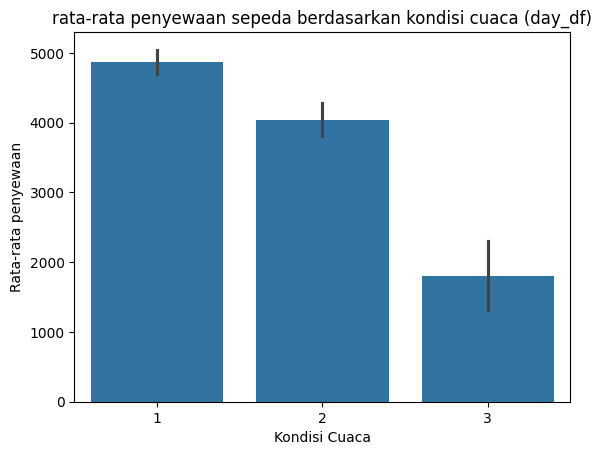

In [61]:
sns.barplot(x='weathersit', y='cnt', data=day_df)
plt.title('rata-rata penyewaan sepeda berdasarkan kondisi cuaca (day_df)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata penyewaan')
plt.show()



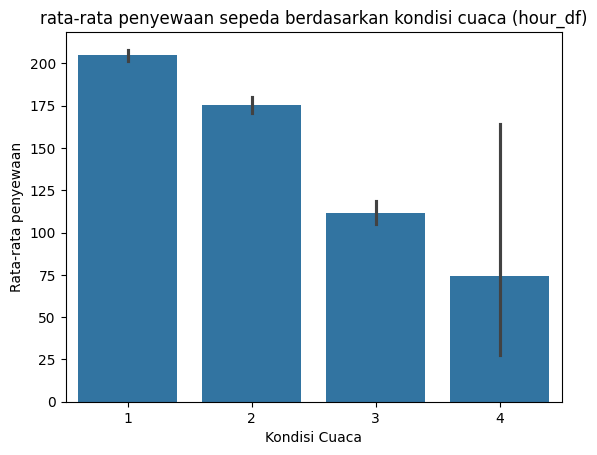

In [62]:
sns.barplot(x='weathersit', y='cnt', data=hour_df)
plt.title('rata-rata penyewaan sepeda berdasarkan kondisi cuaca (hour_df)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata penyewaan')
plt.show()

### Pertanyaan 2: Bagaimana  pola perubahan jumlah penyewaan sepeda (cnt) dalam 24 jam?

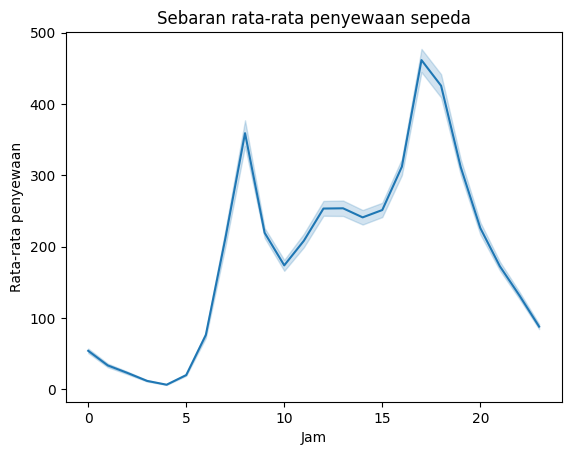

In [63]:
sns.lineplot(x='hr', y='cnt', data=hour_df)
plt.title('Sebaran rata-rata penyewaan sepeda')
plt.xlabel('Jam')
plt.ylabel('Rata-rata penyewaan')
plt.show()

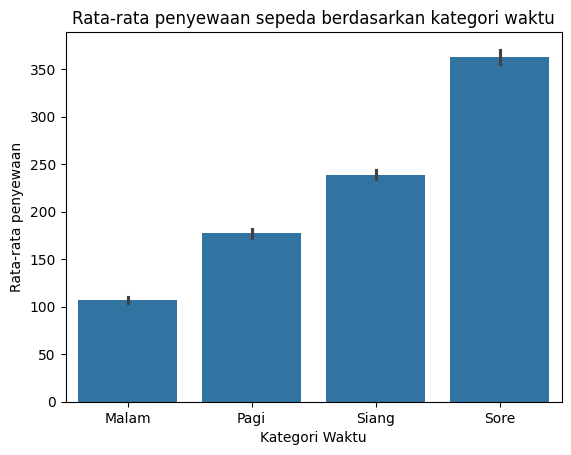

In [64]:
sns.barplot(x='kategori_waktu', y='cnt', data=hour_df)
plt.title('Rata-rata penyewaan sepeda berdasarkan kategori waktu')
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata penyewaan')
plt.show()

**Insight:**
- Jadi, dari visualisasi data pada pertanyaan 1 kita bisa melihat faktor cuaca (weathersit) ini sangat berpengaruh dalam penyewaan sepeda, pada kedua tabel tersebut bisa dilihat pada barplotnya bahwa semakin bagus cuacanya (weathersit) maka akan semakin banyak terjadi penyewaan sepeda.
- Jadi, dari visualisasi data pertanyaan 2 kita bisa melihat jelas bahwa penggunaan sepeda paling banyak terjadi pada sore hari. Puncak penyewaan sepeda terjadi di dua waktu yaitu pukul 08.00 dengan total 359 penyewa dan pukul 17.00 dengan rata-rata penyewaan sepeda mencapai 461 orang. ini menunjukkan bahwa banyak aktivitas masyarakat yang menggunakan sepeda pada pukul 08.00 dan 17.00 seperti berangkat ataupun pulang kerja, berolahraga, dan lain-lain.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 : Cuaca sangat berhubungan/berpengaruh pada banyaknya penyewaan sepeda. pada dua tabel yang saya analisis yaitu day_df dan hour_df ditunjukkan bahwa Semakin bagus cuacanya maka akan semakin banyak pula orang yang menggunakan sepeda
- Conclution pertanyaan 2 : Setelah melakukan analisis diperoleh pola penyewaan sepeda berdasarkan jam, ditemukan bahwa penyewaan sepeda paling banyak terjadi di sore hari. Puncak penyelwaan sepeda terjadi pada dua waktu yaitu pada pukul 08.00 dengan rata-rata penyewa 359 dan pukul 17.00 dengan rata-rata penyewaan sepeda sebanyak 461 orang

